<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

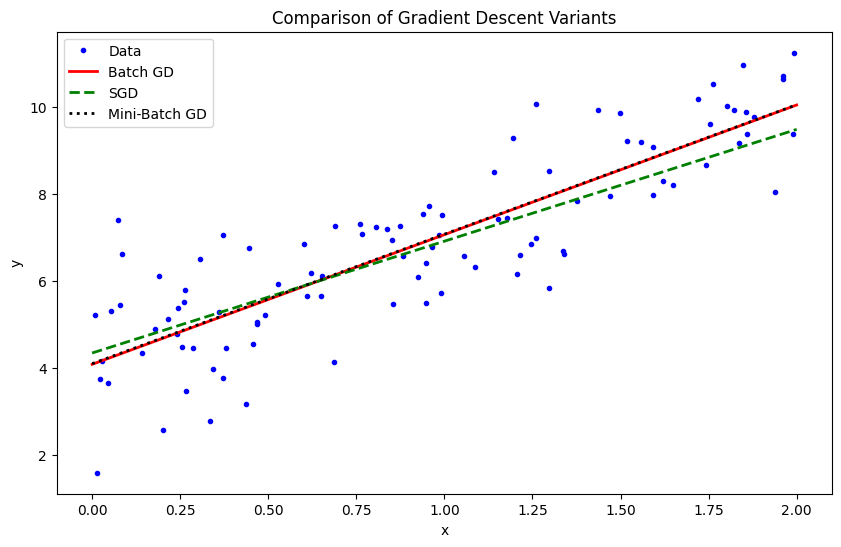

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (if not already defined)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
X_b = np.c_[np.ones((100, 1)), X] # add x0 = 1 to each instance

# Batch Gradient Descent
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    m = len(y)
    for iteration in range(n_iterations):
        gradients = 2/m * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
    return theta, None, None # Returning a tuple to match the unpack in the original code

# Stochastic Gradient Descent
def stocashtic_gradient_descent(X, y, theta, learning_rate, n_iterations):
    m = len(y)
    for i in range(n_iterations):
        random_index = np.random.randint(m)
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - learning_rate * gradients
    return theta, None # Returning a tuple to match the unpack in the original code

# Mini-Batch Gradient Descent
def minibatch_gradient_descent(X, y, theta, learning_rate, n_iterations, batch_size=10):
    m = len(y)
    for iteration in range(n_iterations):
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            gradients = 2/batch_size * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
    return theta, None # Returning a tuple to match the unpack in the original code


# Rerun all three for comparison
# Batch
lr_batch = 0.1
n_iter_batch = 200
y_pred_batch_final, _, _ = gradient_descent(X_b, y, np.random.randn(2,1), lr_batch, n_iter_batch)

# SGD
lr_sgd = 0.05
n_iter_sgd = 200
y_pred_sgd_final, _ = stocashtic_gradient_descent(X_b, y, np.random.randn(2,1), lr_sgd, n_iter_sgd)

# Mini-Batch
lr_mini = 0.1
n_iter_mini = 200
y_pred_mini_final, _ = minibatch_gradient_descent(X_b, y, np.random.randn(2,1), lr_mini, n_iter_mini)


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'b.', label='Data')
# Create a set of X values for plotting the lines
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
# Get predictions for the lines
y_predict_batch = X_new_b.dot(y_pred_batch_final)
y_predict_sgd = X_new_b.dot(y_pred_sgd_final)
y_predict_mini = X_new_b.dot(y_pred_mini_final)

plt.plot(X_new, y_predict_batch, 'r-', linewidth=2, label='Batch GD')
plt.plot(X_new, y_predict_sgd, 'g--', linewidth=2, label='SGD')
plt.plot(X_new, y_predict_mini, 'k:', linewidth=2, label='Mini-Batch GD')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent Variants')
plt.legend()
plt.show()

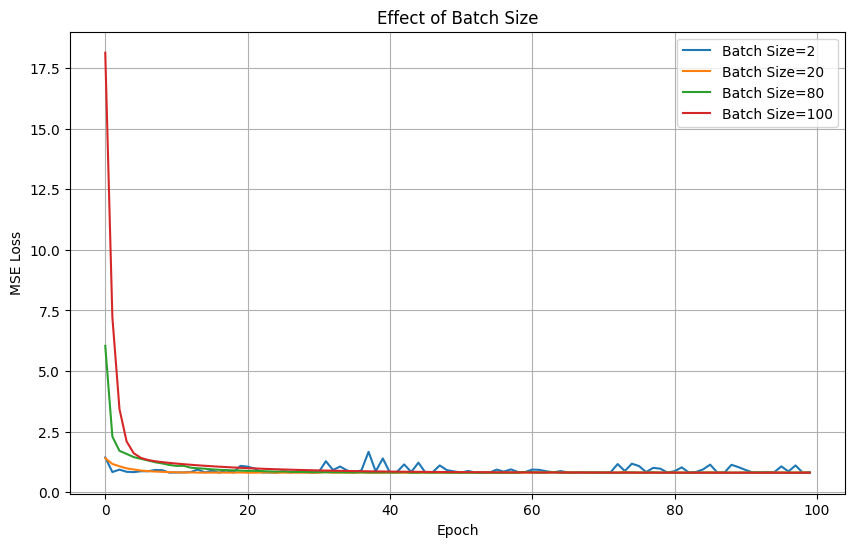

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]

# Mini-Batch Gradient Descent
def mini_batch_gd(X, y, learning_rate=0.1, epochs=100, batch_size=20):
    m, n = X.shape
    theta = np.random.randn(n, 1)
    losses = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            gradients = (2 / len(X_batch)) * X_batch.T @ (
                X_batch @ theta - y_batch
            )

            theta -= learning_rate * gradients

        loss = np.mean((X @ theta - y) ** 2)
        losses.append(loss)

    return theta, losses

batch_sizes = [2, 20, 80, 100]

plt.figure(figsize=(10, 6))

for bs in batch_sizes:
    _, losses = mini_batch_gd(X_b, y, batch_size=bs)
    plt.plot(losses, label=f'Batch Size={bs}')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Effect of Batch Size")
plt.legend()
plt.grid()
plt.show()

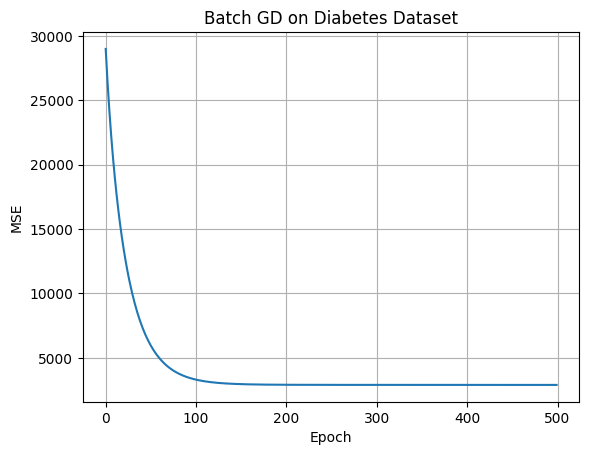

Test MSE: 2885.3478283086824


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = load_diabetes()
X = data.data
y = data.target.reshape(-1, 1)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias term
X = np.c_[np.ones((X.shape[0], 1)), X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Batch GD
def batch_gd(X, y, lr=0.01, epochs=500):
    m, n = X.shape
    theta = np.random.randn(n, 1)
    losses = []

    for _ in range(epochs):
        gradients = (2/m) * X.T @ (X @ theta - y)
        theta -= lr * gradients

        losses.append(np.mean((X @ theta - y)**2))

    return theta, losses

theta, losses = batch_gd(X_train, y_train)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Batch GD on Diabetes Dataset")
plt.grid()
plt.show()

test_mse = np.mean((X_test @ theta - y_test)**2)
print("Test MSE:", test_mse)

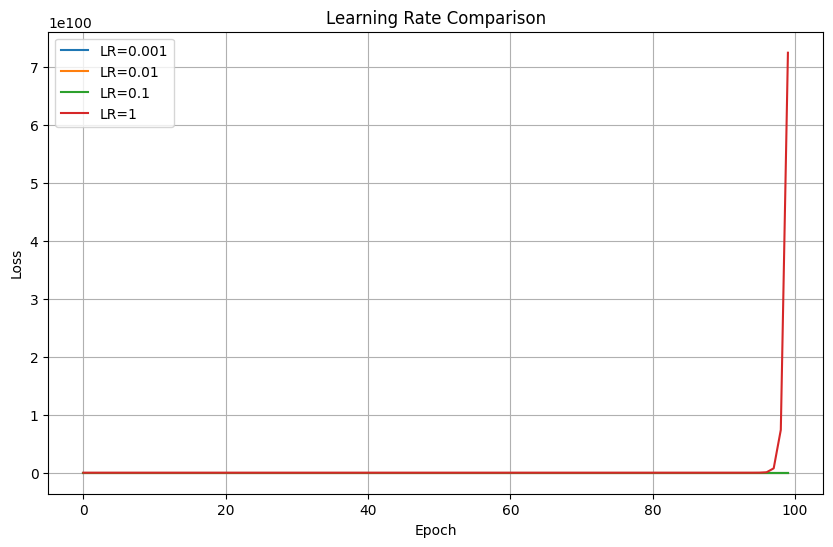

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

# Batch GD
def batch_gd(X, y, lr, epochs=100):
    m, n = X.shape
    theta = np.random.randn(n, 1)
    losses = []

    for _ in range(epochs):
        gradients = (2/m) * X.T @ (X @ theta - y)
        theta -= lr * gradients
        losses.append(np.mean((X @ theta - y)**2))

    return losses

learning_rates = [0.001, 0.01, 0.1, 1]

plt.figure(figsize=(10,6))

for lr in learning_rates:
    losses = batch_gd(X_b, y, lr)
    plt.plot(losses, label=f'LR={lr}')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid()
plt.show()

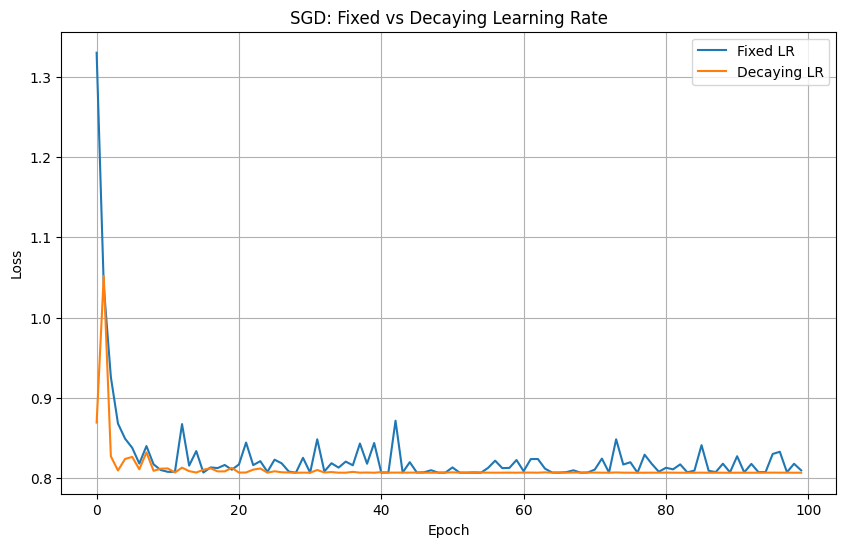

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

def sgd_with_decay(X, y, initial_lr=0.1, epochs=100):
    m, n = X.shape
    theta = np.random.randn(n, 1)

    losses = []

    for epoch in range(epochs):

        lr = initial_lr / (epoch + 1)

        indices = np.random.permutation(m)

        for idx in indices:
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]

            gradients = 2 * xi.T @ (xi @ theta - yi)

            theta -= lr * gradients

        loss = np.mean((X @ theta - y) ** 2)
        losses.append(loss)

    return theta, losses

# Fixed LR
def sgd_fixed(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    theta = np.random.randn(n, 1)

    losses = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)

        for idx in indices:
            xi = X[idx:idx+1]
            yi = y[idx:idx+1]

            gradients = 2 * xi.T @ (xi @ theta - yi)

            theta -= lr * gradients

        loss = np.mean((X @ theta - y) ** 2)
        losses.append(loss)

    return theta, losses

_, fixed_losses = sgd_fixed(X_b, y)
_, decay_losses = sgd_with_decay(X_b, y)

plt.figure(figsize=(10,6))
plt.plot(fixed_losses, label="Fixed LR")
plt.plot(decay_losses, label="Decaying LR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGD: Fixed vs Decaying Learning Rate")
plt.legend()
plt.grid()
plt.show()